## Lots of Plots 

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pypsa


def find_solved_network(root=Path("../saved"), preferred_year="2018"):
    candidates = sorted(root.glob("*/*.nc"))
    if not candidates:
        raise FileNotFoundError(
            f"No solved network (.nc) files found under {root.resolve()}"
        )

    preferred = [p for p in candidates if preferred_year in p.parts]
    return preferred[0] if preferred else candidates[-1]


network_path = find_solved_network()
n = pypsa.Network(network_path)

print(f"Loaded network: {network_path}")
print(f"Snapshots: {len(n.snapshots)}")
print(f"Buses: {len(n.buses)} | Lines: {len(n.lines)} | Links: {len(n.links)}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Loaded network: ../saved/2018/elec_s_10_ec_lcopt_Co2L-3h.nc
Snapshots: 2920
Buses: 30 | Lines: 8 | Links: 43


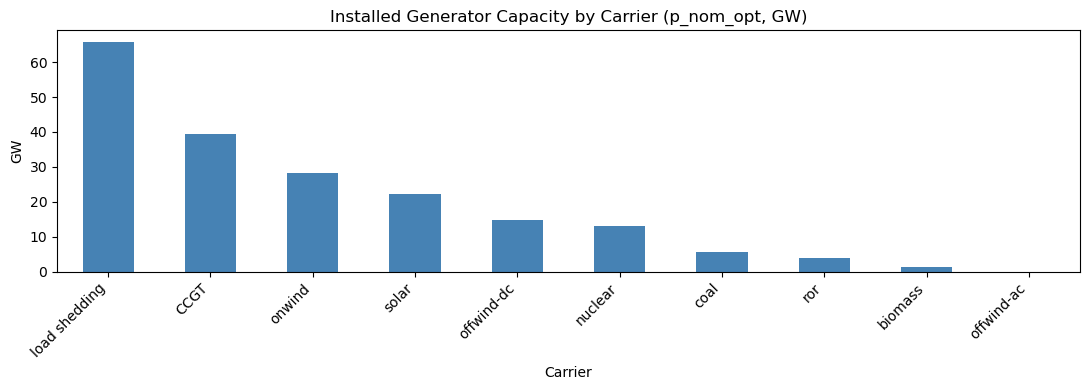

In [29]:
cap_col = "p_nom_opt" if "p_nom_opt" in n.generators.columns else "p_nom"
cap_by_carrier = (
    n.generators.groupby("carrier")[cap_col].sum().sort_values(ascending=False)
    / 1e3
)

fig, ax = plt.subplots(figsize=(11, 4))
cap_by_carrier.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Installed Generator Capacity by Carrier ({cap_col}, GW)")
ax.set_ylabel("GW")
ax.set_xlabel("Carrier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Voronoi Subdivision Of Bus Regions
This reproduces the Voronoi partition approach used in the project code to split each country into nearest-bus service regions.

Keep in mind here that the model CALCULATES Voronoi cells, this isn't pulled from the model output


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/tmp/ipykernel_12808/274502444.py:42: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  uk_geom = uk_outline.unary_union if not uk_outline.empty else None


Panel 1 raw buses: 1574
Panel 2 LV buses: 1176
Panel 3 solved buses / unique coords: 30/10


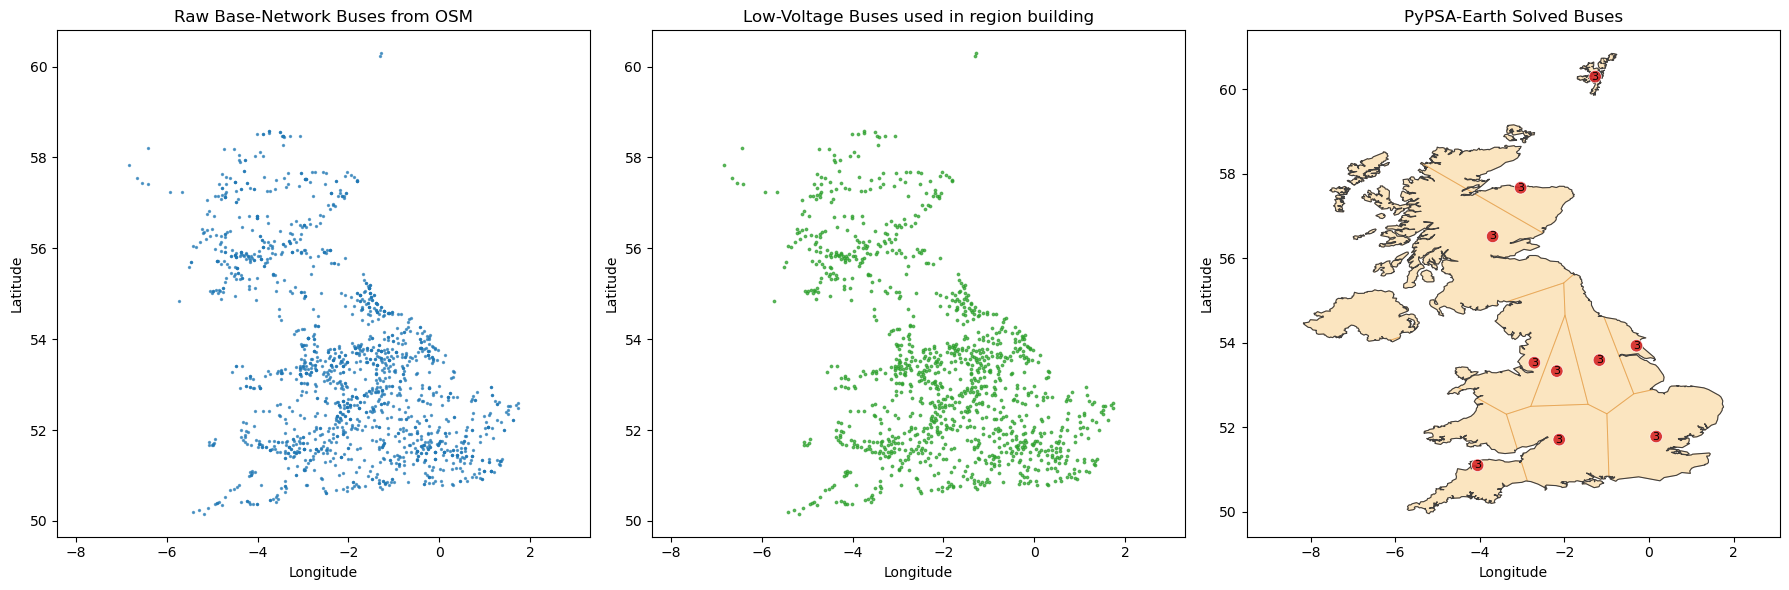

In [30]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pypsa
from scipy.spatial import Voronoi
from shapely.geometry import Polygon

print('====================================================')
print("Keep in mind here that the model CALCULATES Voronoi cells, this isn't pulled from the model output")
print('====================================================')
# 1) Pre-solve raw buses from base_network outputs
raw_buses = gpd.read_file("../resources/base_network/all_buses_build_network.geojson")
raw_buses = raw_buses[raw_buses.geometry.notna()]

# 2) LV substations used for region building
if "substation_lv" in raw_buses.columns:
    lv_buses = raw_buses[raw_buses["substation_lv"].fillna(False)]
else:
    lv_buses = raw_buses.copy()

# 3) Final solved network buses
def _find_solved_nc(root=Path("../saved")):
    files = sorted(root.glob("*/*.nc"))
    if not files:
        raise FileNotFoundError(f"No solved .nc found under {root.resolve()}")
    pref = [p for p in files if "2018" in p.parts]
    return pref[0] if pref else files[-1]

n_final = pypsa.Network(_find_solved_nc())
final_buses = n_final.buses.dropna(subset=["x", "y"]).copy()
final_counts = final_buses.groupby(["x", "y"]).size().rename("count").reset_index()

# UK outline for context on solved-bus panel
country_shapes = gpd.read_file("../resources/shapes/country_shapes.geojson")
if "name" in country_shapes.columns:
    uk_outline = country_shapes[country_shapes["name"].astype(str).isin(["GB", "UK"])]
else:
    uk_outline = country_shapes.copy()

uk_geom = uk_outline.unary_union if not uk_outline.empty else None


def clipped_voronoi_cells(points, outline=None, multiplier=5):
    points = np.asarray(points)
    if len(points) == 0:
        return []
    if len(points) == 1:
        return [outline] if outline is not None else []

    xmin, ymin = np.amin(points, axis=0)
    xmax, ymax = np.amax(points, axis=0)

    if outline is not None and not outline.is_empty:
        minx_o, miny_o, maxx_o, maxy_o = outline.boundary.bounds
        xmin = min(xmin, minx_o)
        ymin = min(ymin, miny_o)
        xmax = max(xmax, maxx_o)
        ymax = max(ymax, maxy_o)

    xspan = max(xmax - xmin, 1e-6)
    yspan = max(ymax - ymin, 1e-6)

    vor = Voronoi(
        np.vstack(
            (
                points,
                [
                    [xmin - multiplier * xspan, ymin - multiplier * yspan],
                    [xmin - multiplier * xspan, ymax + multiplier * yspan],
                    [xmax + multiplier * xspan, ymin - multiplier * yspan],
                    [xmax + multiplier * xspan, ymax + multiplier * yspan],
                ],
            )
        )
    )

    cells = []
    for i in range(len(points)):
        poly = Polygon(vor.vertices[vor.regions[vor.point_region[i]]])
        if not poly.is_valid:
            poly = poly.buffer(0)
        if outline is not None and not outline.is_empty:
            poly = poly.intersection(outline)
        cells.append(poly)

    return cells


vor_cells = clipped_voronoi_cells(final_counts[["x", "y"]].to_numpy(), uk_geom)
voronoi_gdf = gpd.GeoDataFrame({"geometry": vor_cells}, crs=uk_outline.crs)
voronoi_gdf = voronoi_gdf[
    voronoi_gdf.geometry.notna()
    & voronoi_gdf.geometry.is_valid
    & ~voronoi_gdf.geometry.is_empty
]

print(f"Panel 1 raw buses: {len(raw_buses)}")
print(f"Panel 2 LV buses: {len(lv_buses)}")
print(f"Panel 3 solved buses / unique coords: {len(final_buses)}/{len(final_counts)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

raw_buses.plot(ax=axes[0], markersize=2, color="tab:blue", alpha=0.65)
axes[0].set_title("Raw Base-Network Buses from OSM")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

lv_buses.plot(ax=axes[1], markersize=3, color="tab:green", alpha=0.7)
axes[1].set_title("Low-Voltage Buses used in region building") 
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

if not voronoi_gdf.empty:
    voronoi_gdf.plot(
        ax=axes[2],
        facecolor="#f6b64c",
        edgecolor="#d97706",
        alpha=0.35,
        linewidth=0.7,
        zorder=1,
    )

if not uk_outline.empty:
    uk_outline.boundary.plot(ax=axes[2], color="0.25", linewidth=0.8, zorder=2)

axes[2].scatter(
    final_counts["x"],
    final_counts["y"],
    s=20 + 35 * np.sqrt(final_counts["count"]),
    color="tab:red",
    alpha=0.9,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
for _, r in final_counts[final_counts["count"] > 1].iterrows():
    axes[2].text(r["x"], r["y"], str(int(r["count"])), fontsize=8, ha="center", va="center")
axes[2].set_title("PyPSA-Earth Solved Buses")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")

for ax in axes.ravel():
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()

Reference file includes demand: False


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Model snapshot years: [2018]


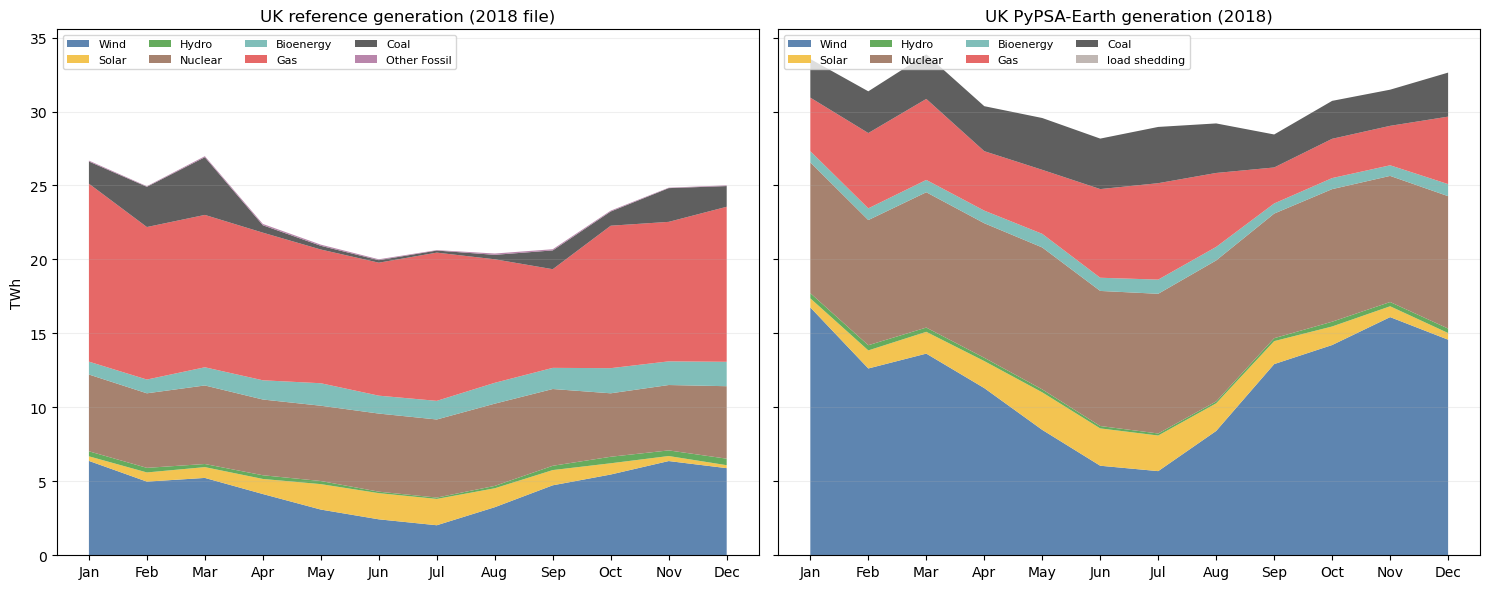

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pypsa

reference_path = Path("../shotton/data/temp-file-uk-2018.csv")
if not reference_path.exists():
    reference_path = Path("data/temp-file-uk-2018.csv")

reference = pd.read_csv(reference_path, parse_dates=["full_date"])
reference_uk = reference[reference["entity_code"] == "GBR"].copy()

reference_generation = reference_uk[
    (~reference_uk["is_aggregate_series"])
    & (reference_uk["series"] != "Total generation")
][ ["full_date", "series", "generation_twh"] ].copy()

series_name_map = {"Other fossil": "Other Fossil"}
reference_generation["series"] = reference_generation["series"].replace(series_name_map)
reference_generation = reference_generation.pivot_table(
    index="full_date", columns="series", values="generation_twh", aggfunc="sum"
).sort_index()

print("Reference file includes demand:", False)

def _find_solved_nc(root=Path("../saved"), preferred_year="2018"):
    files = sorted(root.glob("*/*.nc"))
    if not files:
        raise FileNotFoundError(f"No solved .nc found under {root.resolve()}")
    preferred = [p for p in files if preferred_year in p.parts]
    return preferred[0] if preferred else files[-1]

network_path = _find_solved_nc(preferred_year="2018")
n_model = pypsa.Network(network_path)
model_years = sorted(pd.Index(n_model.snapshots.year).unique())
print("Model snapshot years:", model_years)

uk_buses = n_model.buses.index[n_model.buses["country"].eq("GB")]

carrier_map = {
    "onwind": "Wind",
    "offwind-ac": "Wind",
    "offwind-dc": "Wind",
    "solar": "Solar",
    "solar rooftop": "Solar",
    "hydro": "Hydro",
    "ror": "Hydro",
    "nuclear": "Nuclear",
    "biomass": "Bioenergy",
    "CCGT": "Gas",
    "OCGT": "Gas",
    "coal": "Coal",
    "lignite": "Coal",
    "oil": "Other Fossil",
}

gen_p = n_model.generators_t.p.loc[:, n_model.generators.bus.isin(uk_buses)]
gen_weights = n_model.snapshot_weightings.generators.reindex(gen_p.index)
gen_energy = gen_p.mul(gen_weights, axis=0)
gen_groups = n_model.generators.loc[gen_p.columns, "carrier"].map(carrier_map).fillna(
    n_model.generators.loc[gen_p.columns, "carrier"]
)
model_generation = gen_energy.T.groupby(gen_groups).sum().T

if not n_model.storage_units.empty:
    su = n_model.storage_units[n_model.storage_units.bus.isin(uk_buses)].copy()
    su = su[su.carrier.isin(["hydro", "ror"])]
    if not su.empty:
        su_p = n_model.storage_units_t.p.loc[:, su.index].clip(lower=0)
        su_weights = n_model.snapshot_weightings.generators.reindex(su_p.index)
        su_energy = su_p.mul(su_weights, axis=0)
        su_groups = su["carrier"].map(carrier_map).fillna(su["carrier"])
        su_generation = su_energy.T.groupby(su_groups).sum().T
        model_generation = pd.concat([model_generation, su_generation], axis=1)
        model_generation = model_generation.T.groupby(level=0).sum().T

month_order = list(range(1, 13))
month_labels = pd.Index(pd.date_range("2000-01-01", periods=12, freq="MS").strftime("%b"))

reference_month = reference_generation.groupby(reference_generation.index.month).sum().reindex(month_order, fill_value=0)
reference_month.index = month_labels

model_month = model_generation.groupby(model_generation.index.month).sum().reindex(month_order, fill_value=0) / 1e6
model_month.index = month_labels

colors = {
    "Wind": "#4c78a8",
    "Solar": "#f2be3e",
    "Hydro": "#54a24b",
    "Nuclear": "#9c755f",
    "Bioenergy": "#72b7b2",
    "Gas": "#e45756",
    "Coal": "#4d4d4d",
    "Other Fossil": "#b279a2",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
x = range(len(month_labels))

reference_cols = [c for c in colors if c in reference_month.columns and reference_month[c].sum() > 0]
if reference_cols:
    axes[0].stackplot(
        x,
        *[reference_month[c].values for c in reference_cols],
        labels=reference_cols,
        colors=[colors[c] for c in reference_cols],
        alpha=0.9,
    )
axes[0].set_title("UK reference generation (2018 file)")
axes[0].set_ylabel("TWh")
axes[0].set_xticks(list(x), month_labels)
axes[0].legend(loc="upper left", ncol=4, fontsize=8)

model_cols = [c for c in colors if c in model_month.columns and model_month[c].sum() > 0]
extra_model_cols = [c for c in model_month.columns if c not in colors and model_month[c].sum() > 0]
all_model_cols = model_cols + extra_model_cols
model_colors = [colors.get(c, "#bab0ab") for c in all_model_cols]
if all_model_cols:
    axes[1].stackplot(
        x,
        *[model_month[c].values for c in all_model_cols],
        labels=all_model_cols,
        colors=model_colors,
        alpha=0.9,
    )
axes[1].set_title(f"UK PyPSA-Earth generation ({', '.join(map(str, model_years))})")
axes[1].set_xticks(list(x), month_labels)
axes[1].legend(loc="upper left", ncol=4, fontsize=8)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

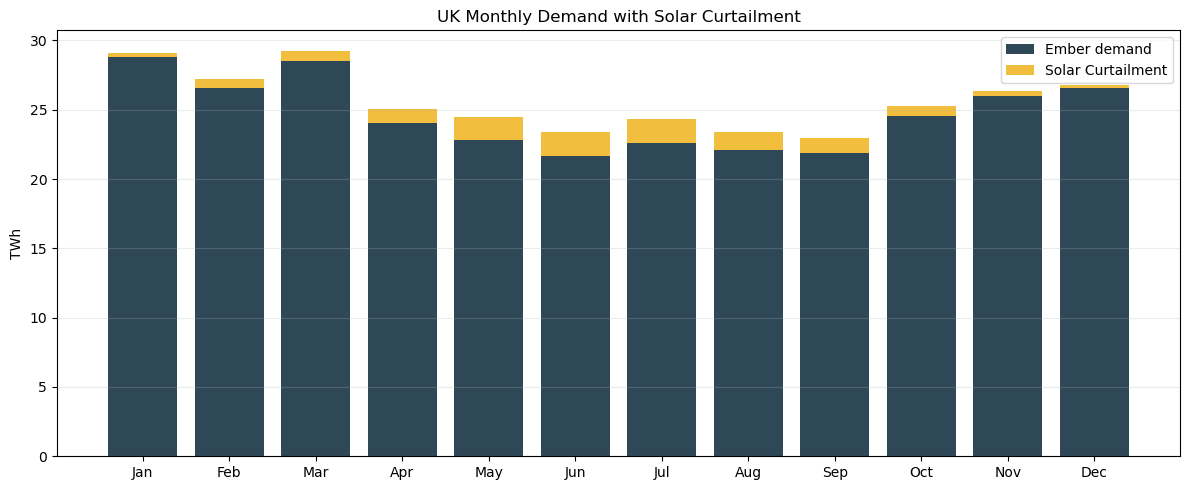

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

reference_path = Path("../shotton/data/temp-file-uk-2018.csv")
if not reference_path.exists():
    reference_path = Path("data/temp-file-uk-2018.csv")

reference = pd.read_csv(reference_path, parse_dates=["full_date"])
reference_uk = reference[reference["entity_code"] == "GBR"].copy()

solar_mask = reference_uk["series"].astype(str).str.lower().eq("solar")
solar_month = (
    reference_uk.loc[solar_mask]
    .groupby(reference_uk.loc[solar_mask, "full_date"].dt.month)["generation_twh"]
    .sum()
    .reindex(range(1, 13), fill_value=0.0)
)

# Use Ember demand from the same CSV for the base layer.
if "demand_twh" in reference_uk.columns:
    demand_month = (
        reference_uk.dropna(subset=["demand_twh"])
        .groupby(reference_uk.dropna(subset=["demand_twh"])["full_date"].dt.month)["demand_twh"]
        .mean()
        .reindex(range(1, 13), fill_value=0.0)
    )
else:
    demand_month = pd.Series(
        [28.82, 26.59, 28.54, 24.04, 22.79, 21.64, 22.58, 22.09, 21.91, 24.53, 26.03, 26.58],
        index=range(1, 13),
        dtype=float,
    )

plot_df = pd.DataFrame(
    {
        "Demand": demand_month.values,
        "Additional Solar (from CSV)": solar_month.values,
    },
    index=pd.Index(pd.date_range("2000-01-01", periods=12, freq="MS").strftime("%b"), name="Month"),
)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(plot_df.index))

lower_color = "#2f4858"
solar_orange = "#f2be3e"

ax.bar(x, plot_df["Demand"], color=lower_color, label="Ember demand")
ax.bar(
    x,
    plot_df["Additional Solar (from CSV)"],
    bottom=plot_df["Demand"],
    color=solar_orange,
    label="Solar Curtailment",
)

ax.set_xticks(list(x), plot_df.index)
ax.set_ylabel("TWh")
ax.set_title("UK Monthly Demand with Solar Curtailment")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

Nodes plotted: 10
Annual Solar Curtailment allocated: 19.24 TWh


,node_label,x,y,bus_count,allocation_share,allocated_proxy_twh
0,N1,-2.1796,53.3305,3,0.2276,4.3783
1,N2,-3.6968,56.5156,3,0.2218,4.2665
2,N3,0.1699,51.7841,3,0.1396,2.6859
3,N4,-1.1731,53.5905,3,0.0939,1.8069
4,N5,-0.2959,53.9305,3,0.0873,1.6805
5,N6,-2.1224,51.7101,3,0.0823,1.5838
6,N7,-2.7101,53.5297,3,0.0704,1.3554
7,N8,-4.0520,51.1036,3,0.0654,1.2585
8,N9,-1.2731,60.2926,3,0.0104,0.1997
9,N10,-3.0348,57.6654,3,0.0013,0.0245


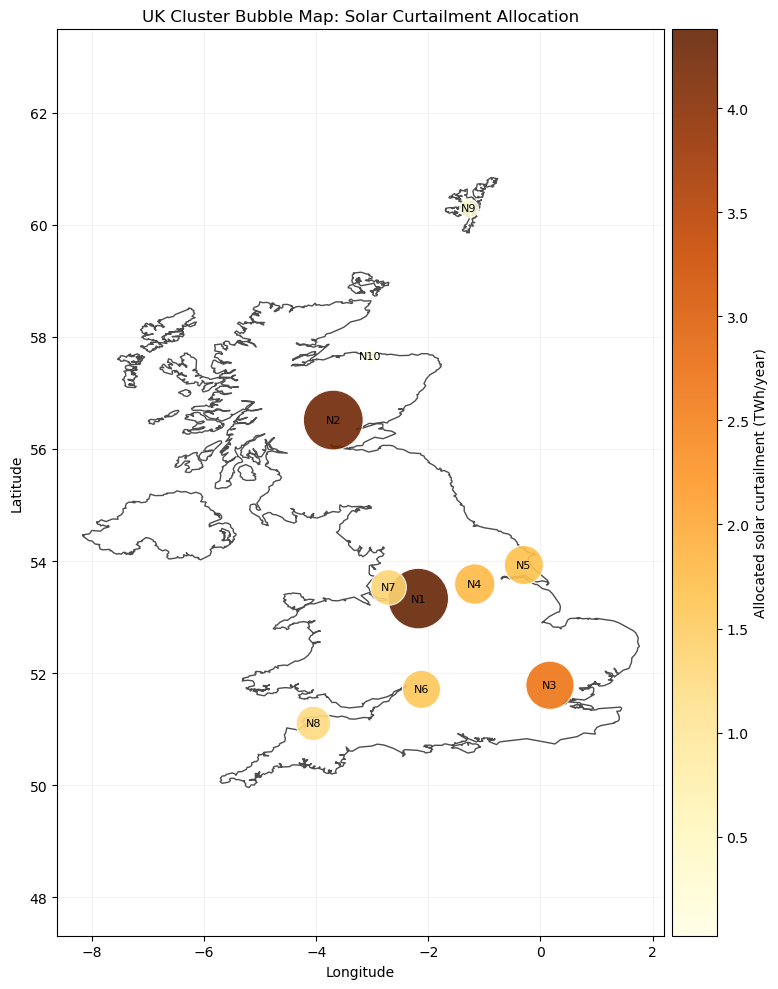

In [38]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# 1) Load solved network (prefer already-loaded object).
if "n_model" in globals():
    n_map = n_model
elif "n" in globals():
    n_map = n
else:
    def _find_solved_nc(root=Path("../saved"), preferred_year="2018"):
        files = sorted(root.glob("*/*.nc"))
        if not files:
            raise FileNotFoundError(f"No solved .nc found under {root.resolve()}")
        preferred = [p for p in files if preferred_year in p.parts]
        return preferred[0] if preferred else files[-1]

    n_map = pypsa.Network(_find_solved_nc(preferred_year="2018"))

# 2) Ember monthly demand/generation and annual proxy gap (Demand - Generation).
reference_path = Path("../shotton/data/temp-file-uk-2018.csv")
if not reference_path.exists():
    reference_path = Path("data/temp-file-uk-2018.csv")

ember = pd.read_csv(reference_path, parse_dates=["full_date"])
uk = ember[ember["entity_code"] == "GBR"].copy()

if "demand_twh" in uk.columns:
    ember_demand_month = (
        uk.dropna(subset=["demand_twh"])
        .groupby(uk.dropna(subset=["demand_twh"])["full_date"].dt.month)["demand_twh"]
        .mean()
        .reindex(range(1, 13), fill_value=0.0)
    )
else:
    ember_demand_month = pd.Series(
        [28.82, 26.59, 28.54, 24.04, 22.79, 21.64, 22.58, 22.09, 21.91, 24.53, 26.03, 26.58],
        index=range(1, 13),
        dtype=float,
    )

total_mask = uk["series"].astype(str).str.lower().eq("total generation")
if total_mask.any():
    ember_generation_month = (
        uk.loc[total_mask]
        .groupby(uk.loc[total_mask, "full_date"].dt.month)["generation_twh"]
        .sum()
        .reindex(range(1, 13), fill_value=0.0)
    )
else:
    ember_generation_month = (
        uk[~uk["is_aggregate_series"]]
        .groupby(uk.loc[~uk["is_aggregate_series"], "full_date"].dt.month)["generation_twh"]
        .sum()
        .reindex(range(1, 13), fill_value=0.0)
    )

solar_proxy_annual_twh = float((ember_demand_month - ember_generation_month).clip(lower=0.0).sum())

# 3) Build UK node table (cluster nodes represented by unique solved bus coordinates).
uk_buses = n_map.buses[n_map.buses["country"].eq("GB")].dropna(subset=["x", "y"]).copy()
if uk_buses.empty:
    raise ValueError("No UK buses with coordinates found.")

uk_buses["node_key"] = uk_buses["x"].round(5).astype(str) + "|" + uk_buses["y"].round(5).astype(str)
nodes = uk_buses.groupby("node_key", as_index=False).agg(
    x=("x", "first"),
    y=("y", "first"),
    bus_count=("x", "size"),
)

# 4) Logical split: allocate annual solar proxy by each node's model solar generation share.
solar_carriers = ["solar", "solar rooftop"]
uk_solar_gens = n_map.generators.index[
    n_map.generators.bus.isin(uk_buses.index) & n_map.generators.carrier.isin(solar_carriers)
]

if len(uk_solar_gens) > 0:
    weights = n_map.snapshot_weightings.generators.reindex(n_map.snapshots)
    solar_energy = n_map.generators_t.p.loc[:, uk_solar_gens].mul(weights, axis=0) / 1e6
    solar_bus = n_map.generators.loc[uk_solar_gens, "bus"]
    solar_by_bus = solar_energy.T.groupby(solar_bus).sum().sum(axis=1)

    bus_to_node = uk_buses["node_key"]
    solar_by_node = solar_by_bus.groupby(bus_to_node.reindex(solar_by_bus.index)).sum()
else:
    solar_by_node = pd.Series(dtype=float)

nodes = nodes.set_index("node_key")
nodes["model_solar_twh"] = solar_by_node.reindex(nodes.index).fillna(0.0)
total_model_solar = float(nodes["model_solar_twh"].sum())

if total_model_solar > 0:
    nodes["allocation_share"] = nodes["model_solar_twh"] / total_model_solar
else:
    nodes["allocation_share"] = 1.0 / len(nodes)

nodes["allocated_proxy_twh"] = nodes["allocation_share"] * solar_proxy_annual_twh
nodes = nodes.reset_index().sort_values("allocated_proxy_twh", ascending=False).reset_index(drop=True)
nodes["node_label"] = [f"N{i+1}" for i in range(len(nodes))]

# 5) Plot bubble map.
country_shapes = gpd.read_file("../resources/shapes/country_shapes.geojson")
if "name" in country_shapes.columns:
    uk_outline = country_shapes[country_shapes["name"].astype(str).isin(["GB", "UK"])]
else:
    uk_outline = country_shapes.copy()

fig, ax = plt.subplots(figsize=(8, 10))
if not uk_outline.empty:
    uk_outline.boundary.plot(ax=ax, color="0.3", linewidth=1.0, zorder=1)

size_scale = 1800
sizes = 100 + size_scale * nodes["allocated_proxy_twh"] / max(nodes["allocated_proxy_twh"].max(), 1e-9)
sc = ax.scatter(
    nodes["x"],
    nodes["y"],
    s=sizes,
    c=nodes["allocated_proxy_twh"],
    cmap="YlOrBr",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
)

for _, row in nodes.iterrows():
    ax.text(row["x"], row["y"], row["node_label"], fontsize=8, ha="center", va="center", zorder=4)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("Allocated solar curtailment (TWh/year)")

ax.set_title("UK Cluster Bubble Map: Solar Curtailment Allocation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.15)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()

print(f"Nodes plotted: {len(nodes)}")
print(f"Annual Solar Curtailment allocated: {solar_proxy_annual_twh:.2f} TWh")
display(nodes[["node_label", "x", "y", "bus_count", "allocation_share", "allocated_proxy_twh"]].round(4))